In [95]:
# Importation of necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [96]:
titanic_df = pd.read_csv('train.csv')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [97]:
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [98]:
overall_survival_rate = titanic_df['Survived'].value_counts(normalize=True) * 100
overall_survival_rate 

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [99]:
survival_rate_by_sex = titanic_df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()* 100
survival_rate_by_sex

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [100]:
survival_rate_by_class = titanic_df.groupby('Pclass')['Survived'].value_counts(normalize=True).unstack() * 100
survival_rate_by_class

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [101]:
titanic_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [102]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [103]:
survival_rate_by_age_group = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=[0, 18, 80]))['Survived'].value_counts(normalize=True).unstack() * 100
survival_rate_by_age_group

C:\Users\HP\AppData\Local\Temp\ipykernel_21092\3440199474.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_age_group = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=[0, 18, 80]))['Survived'].value_counts(normalize=True).unstack() * 100


Survived,0,1
Age,,
"(0, 18]",49.640288,50.359712
"(18, 80]",63.829787,36.170213


<Axes: xlabel='Sex', ylabel='Survived'>

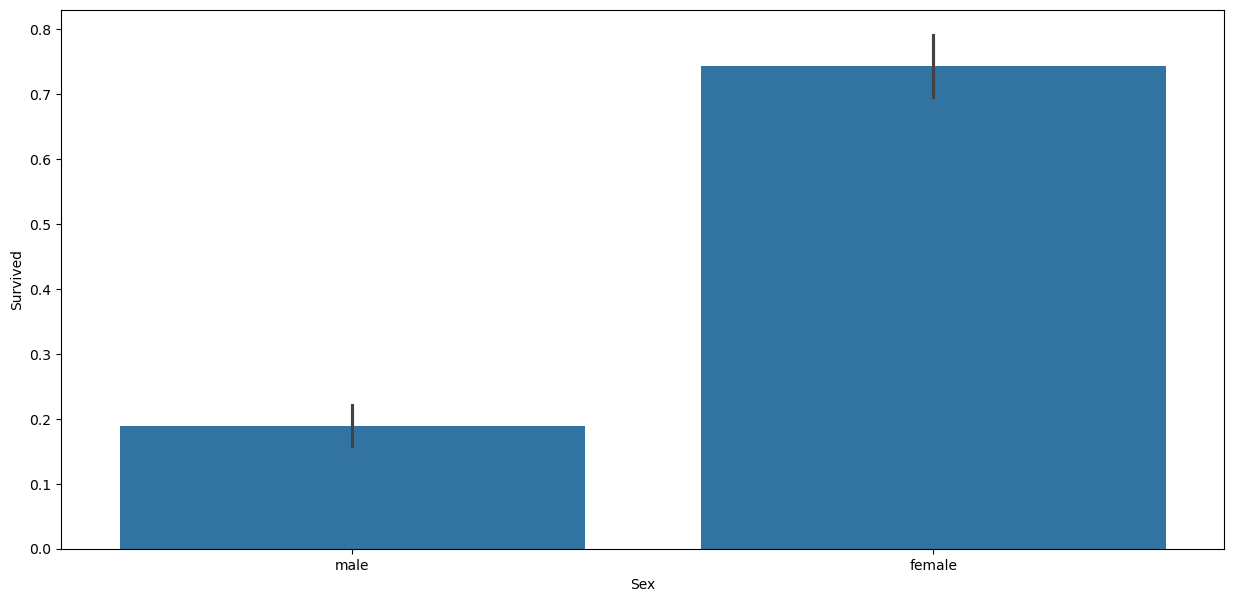

In [104]:
# Visualisation of survival rates by sex
plt.figure(figsize=(15, 7))
sns.barplot(x = 'Sex', y = 'Survived', data = titanic_df )

<Axes: xlabel='Pclass', ylabel='Survived'>

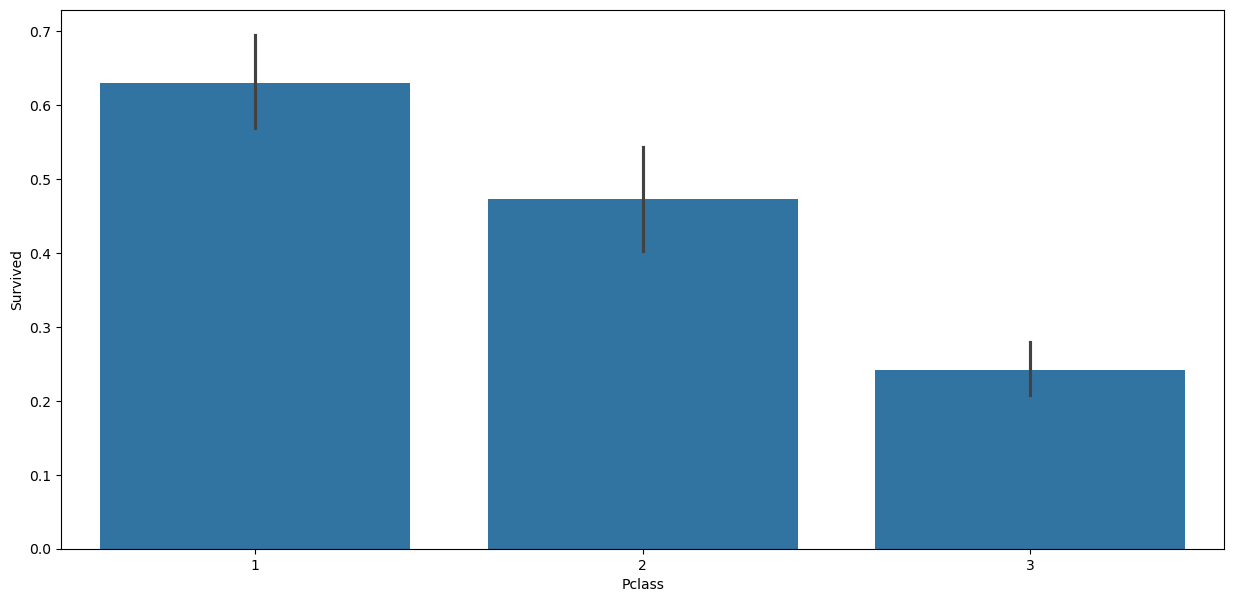

In [105]:
# Visualisation of survival rates by class
plt.figure(figsize=(15, 7))
sns.barplot(x = 'Pclass', y = 'Survived', data = titanic_df )

<Axes: xlabel='Age', ylabel='Survived'>

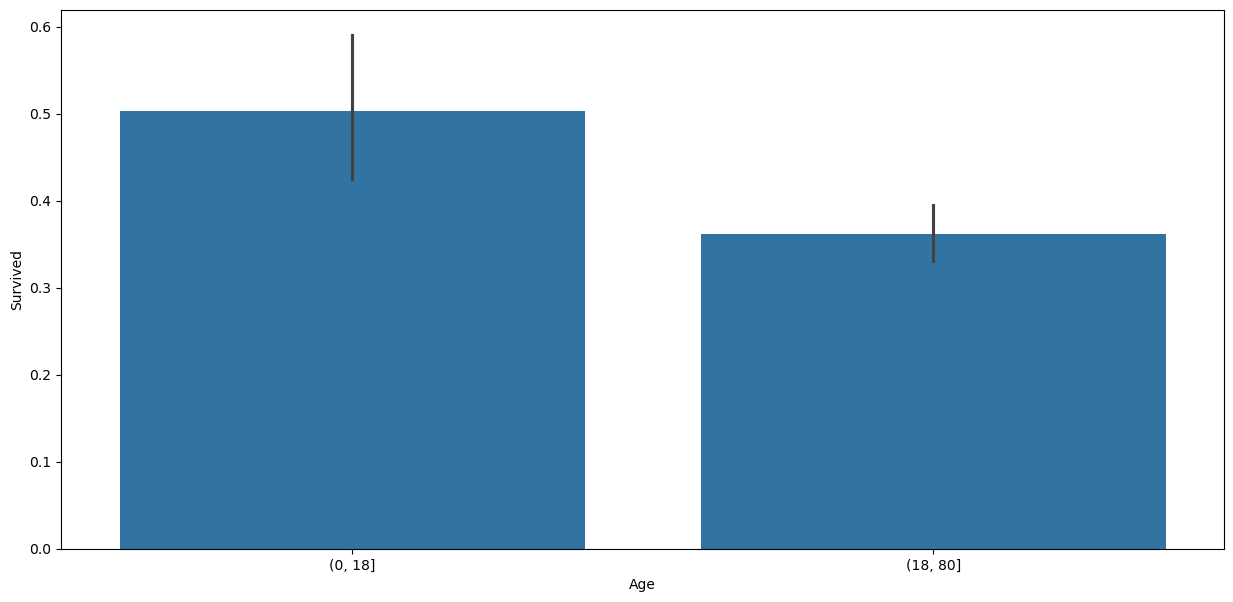

In [106]:
# Visualisation of survival rates by age group
plt.figure(figsize=(15, 7))
sns.barplot(x = pd.cut(titanic_df['Age'], bins=[0, 18, 80]), y = 'Survived', data = titanic_df )

Text(0, 0.5, 'Survival Rate')

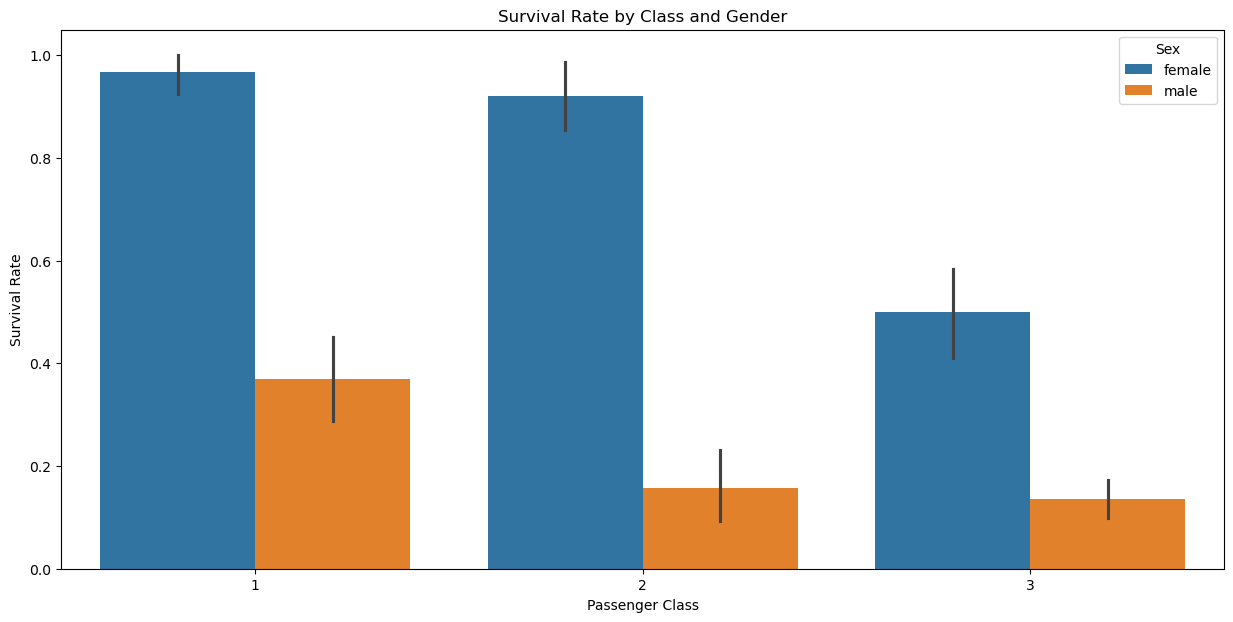

In [107]:
# Visualizing survival rate by class and gender
plt.figure(figsize=(15, 7))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

In [108]:
# Cleaning of the columns Embarked
titanic_df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [109]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')
titanic_df['Embarked'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Embarked
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [110]:
# Verifying the link between the Cabin and Pclass columns (correlation)
titanic_df.groupby('Pclass')['Cabin'].count()

Pclass
1    176
2     16
3     12
Name: Cabin, dtype: int64

In [111]:
# Cleaning of the columns Cabin
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [112]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [113]:
# Encoding
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1 })
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Unknown,S


In [114]:
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category').cat.codes
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Unknown,2
